# Animal Classification from Camera Trap Images

**Course:** Neural Networks  
**Project stage:** Project Topic Meeting  
**Dataset:** iWildCam  

## Project Members
- Kamila Korczyńska
- Kamil Tasarz


## Project Aim

This project focuses on **animal classification from camera trap images**. The goal is to develop a neural network model that predicts the animal class shown in an input image from the **iWildCam** dataset.

The project is designed as a reproducible semester assignment for a two-person team. The focus is on a clear problem definition, a strong baseline, and well-structured analysis rather than on building a production system.

## Problem Formulation

We define the project as a **supervised multi-class image classification task**.

Let

$\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}$,

where:
- $x_i \in \mathbb{R}^{H \times W \times C}$ is a camera trap image,
- $y_i \in \mathcal{L}$ is the corresponding class label,
- $\mathcal{L} = \{\ell_1, \ell_2, \dots, \ell_K\}$ is the set of target animal classes.

**Input:** one camera trap image  
**Output:** one predicted animal class  
**Objective:** learn a function

$f: \mathbb{R}^{H \times W \times C} \rightarrow \mathcal{L}$

that correctly classifies previously unseen images.

In short, the project studies how well a neural network can generalize from labeled camera trap data to new wildlife images.

## Motivation

Camera traps generate large amounts of ecological data, but manual annotation is slow and expensive. Automatic image classification can support biodiversity monitoring, wildlife studies, and conservation work by reducing labeling effort.

This is also a strong machine learning project topic because it is a real-world **image classification** problem. The images are captured in uncontrolled conditions, which makes the task more challenging and more meaningful than a simplified classroom dataset.

## Dataset: iWildCam

We plan to use **iWildCam**, a dataset built from real-world wildlife camera trap images. It is directly aligned with our topic because the input data are the same type of images that our model is expected to classify.

A typical data point consists of:
- one camera trap image,
- one class label describing the animal category,
- optional metadata or annotation fields, depending on the dataset release.

This makes the dataset a natural fit for a supervised **image classification** task.

### Why this dataset fits the project

The dataset is suitable because it combines practical relevance with realistic difficulty. Since the images come from real camera traps, they may include difficult lighting, background clutter, occlusion, motion blur, and empty or ambiguous frames. These conditions make the project meaningful for both modeling and analysis.

**Note:** The exact local folder structure and annotation schema will be confirmed after the dataset is downloaded and inspected in our environment.

In [24]:
from pathlib import Path

# Default path for the lightweight development sample.
DATASET_DIR = Path("data/iwildcam_sample")
ANNOTATIONS_PATH = DATASET_DIR / "annotations.json"

# TODO: adjust these candidate folders if the local structure changes.
IMAGE_DIR_CANDIDATES = [
    DATASET_DIR / "images",
    DATASET_DIR / "train",
    DATASET_DIR / "val",
    DATASET_DIR,
]

print("Dataset directory:", DATASET_DIR.resolve())
print("Dataset directory exists:", DATASET_DIR.exists())
print("Annotation file exists:", ANNOTATIONS_PATH.exists())
print("Candidate image directories:")
for candidate in IMAGE_DIR_CANDIDATES:
    print(" -", candidate, "| exists:", candidate.exists())


Dataset directory: C:\Users\user\OneDrive\Desktop\NN-project\data\iwildcam_sample
Dataset directory exists: True
Annotation file exists: True
Candidate image directories:
 - data\iwildcam_sample\images | exists: True
 - data\iwildcam_sample\train | exists: False
 - data\iwildcam_sample\val | exists: False
 - data\iwildcam_sample | exists: True


## Example Data Preview

For the first project meeting, we only need a lightweight visual preview of the dataset. The goal is to confirm that local files can be accessed and to inspect a few example images.

If the dataset is available locally, the next cells will:
- search for image files in a few candidate directories,
- report how many images are currently visible,
- display a few random samples.

If no files are found, the path placeholders should be updated after the local iWildCam structure is confirmed.

Existing candidate directories:
 - data\iwildcam_sample\images
 - data\iwildcam_sample
Found 30 image files.


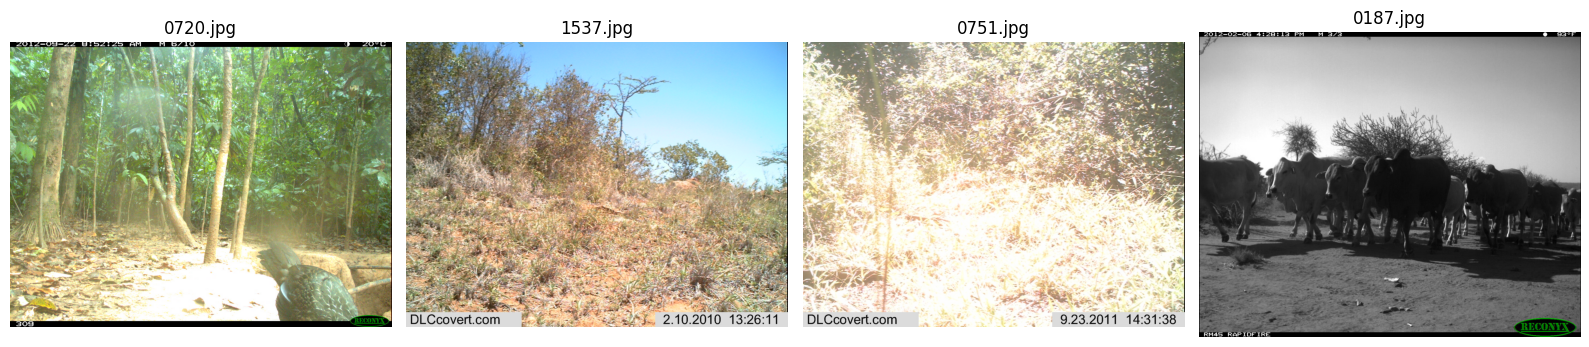

In [25]:
import random

import matplotlib.pyplot as plt
from PIL import Image

image_extensions = {".jpg", ".jpeg", ".png"}

existing_image_dirs = [path for path in IMAGE_DIR_CANDIDATES if path.exists()]
print("Existing candidate directories:")
for directory in existing_image_dirs:
    print(" -", directory)

image_files = []
for directory in existing_image_dirs:
    image_files.extend([p for p in directory.rglob("*") if p.suffix.lower() in image_extensions])

# Remove duplicates in case candidate directories overlap.
image_files = sorted(set(image_files))
print(f"Found {len(image_files)} image files.")

if image_files:
    sample_files = random.sample(image_files, k=min(4, len(image_files)))
    fig, axes = plt.subplots(1, len(sample_files), figsize=(4 * len(sample_files), 4))
    if len(sample_files) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, sample_files):
        try:
            image = Image.open(image_path)
            ax.imshow(image)
            ax.set_title(image_path.name)
            ax.axis("off")
        except Exception as exc:
            ax.text(0.5, 0.5, f"Could not open\n{image_path.name}", ha="center", va="center")
            ax.set_title(type(exc).__name__)
            ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No local image files were found.")
    print("TODO: adjust DATASET_DIR and IMAGE_DIR_CANDIDATES after downloading iWildCam.")


## Preliminary Dataset Inspection

The following exploratory cells are included only to support the first project meeting. They help us inspect labels, visualize basic class frequencies, and identify likely difficulties in the dataset.

This is not a full analysis pipeline. The code is intentionally lightweight and includes explicit assumptions and TODO notes where the local dataset structure may differ.

### Sample Images

A small visual sample helps verify that the local files are accessible and provides an early impression of image variability. Even a few examples can reveal difficult lighting, partial animal visibility, cluttered backgrounds, or frames with no clearly visible subject.

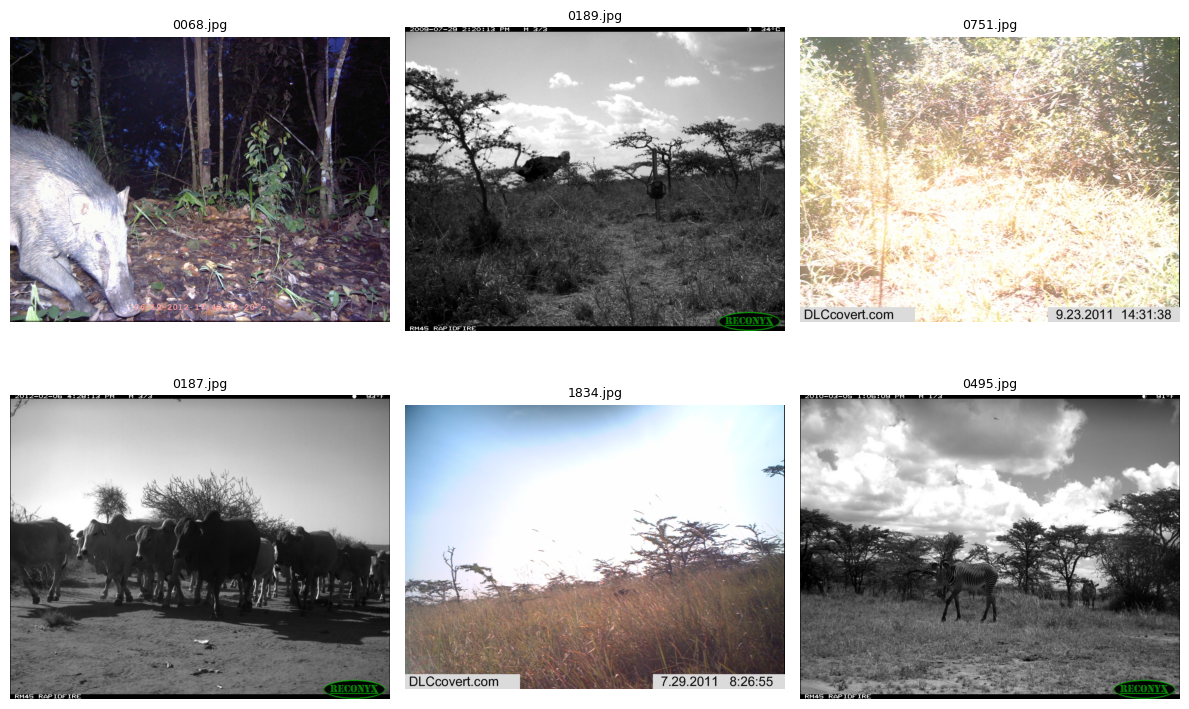

In [26]:
# Display a slightly larger random sample to inspect image diversity.
SAMPLE_IMAGE_COUNT = 6

if image_files:
    sample_files = random.sample(image_files, k=min(SAMPLE_IMAGE_COUNT, len(image_files)))
    n_cols = min(3, len(sample_files))
    n_rows = (len(sample_files) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

    if hasattr(axes, "ravel"):
        axes = list(axes.ravel())
    else:
        axes = [axes]

    for ax, image_path in zip(axes, sample_files):
        try:
            image = Image.open(image_path)
            ax.imshow(image)
            ax.set_title(image_path.name, fontsize=9)
            ax.axis("off")
        except Exception as exc:
            ax.text(0.5, 0.5, f"Could not open\n{image_path.name}", ha="center", va="center")
            ax.set_title(type(exc).__name__)
            ax.axis("off")

    for ax in axes[len(sample_files):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No local image files are available for preview.")
    print("TODO: verify DATASET_DIR and IMAGE_DIR_CANDIDATES.")


### Labels and Classes

For a classification project, it is useful to inspect how labels are stored and whether class names can be recovered from the annotation file. The next cell assumes a JSON-based annotation format and tries a few common patterns in a cautious way.

If the local release uses a different schema, the extraction logic should be adjusted accordingly.

In [27]:
import json
from collections import Counter

import pandas as pd

annotation_data = None
class_id_to_name = {}
label_counts = Counter()

if ANNOTATIONS_PATH.exists():
    with ANNOTATIONS_PATH.open("r", encoding="utf-8") as f:
        annotation_data = json.load(f)

    print("Loaded annotation file:", ANNOTATIONS_PATH)
    if isinstance(annotation_data, dict):
        print("Top-level annotation keys:", sorted(annotation_data.keys()))

        # Assumption: a COCO-like structure may contain category definitions.
        for category in annotation_data.get("categories", []):
            if isinstance(category, dict) and "id" in category:
                class_id_to_name[category["id"]] = category.get("name", str(category["id"]))

        # Assumption: labels may appear as category_id entries inside annotations.
        for annotation in annotation_data.get("annotations", []):
            if isinstance(annotation, dict) and "category_id" in annotation:
                label_counts[annotation["category_id"]] += 1

        # Fallback: some datasets may store label information directly in images or records.
        if not label_counts:
            for item in annotation_data.get("images", []):
                if isinstance(item, dict):
                    for key in ("category_id", "label", "class", "class_id"):
                        if key in item:
                            label_counts[item[key]] += 1
                            break
    else:
        print("Annotation file is not a dictionary. TODO: inspect the local schema manually.")
else:
    print("Annotation file not found.")
    print("TODO: update ANNOTATIONS_PATH after downloading the dataset.")

if label_counts:
    label_df = pd.DataFrame(
        {
            "class_id": list(label_counts.keys()),
            "count": list(label_counts.values()),
        }
    ).sort_values("count", ascending=False)
    label_df["class_name"] = label_df["class_id"].map(class_id_to_name).fillna(label_df["class_id"].astype(str))

    print(f"Detected {len(label_df)} classes with at least one labeled example.")
    display(label_df.head(10))
else:
    label_df = pd.DataFrame(columns=["class_id", "count", "class_name"])
    print("No labels were extracted automatically.")
    print("TODO: adapt the parsing logic to the local annotation format if needed.")


Loaded annotation file: data\iwildcam_sample\annotations.json
Top-level annotation keys: ['annotations', 'categories', 'images', 'info']
Detected 12 classes with at least one labeled example.


,class_id,count,class_name
0,0,19,empty
1,7,1,tapirus terrestris
2,17,1,penelope jacquacu
3,185,1,cebus apella
4,71,1,bos taurus
5,259,1,equus grevyi
6,96,1,aepyceros melampus
7,120,1,struthio camelus
8,144,1,muntiacus muntjak
9,510,1,sus sp


### Basic Class Distribution

A simple class frequency plot is enough at this stage to check whether the dataset is likely to be imbalanced. This matters because class imbalance can strongly affect both model training and the interpretation of evaluation metrics.

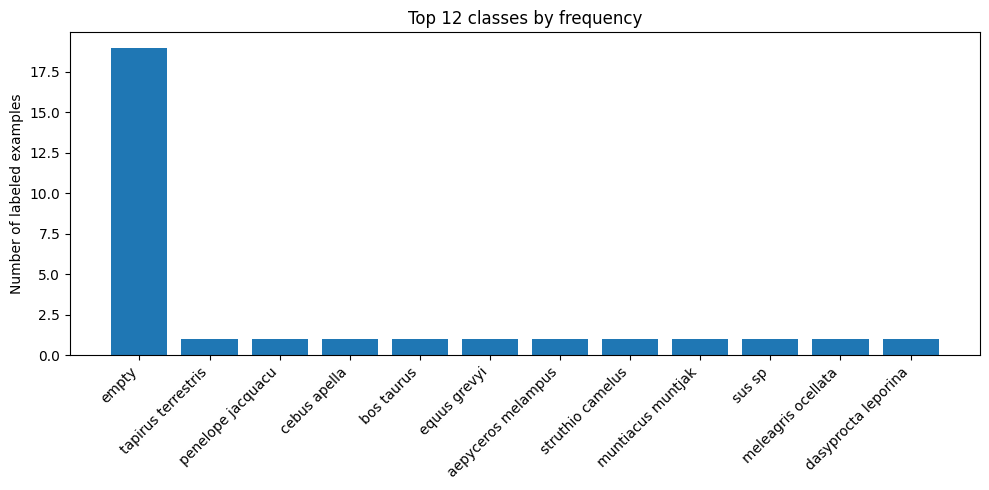

Most frequent classes:


,class_name,count
0,empty,19
1,tapirus terrestris,1
2,penelope jacquacu,1
3,cebus apella,1
4,bos taurus,1
5,equus grevyi,1
6,aepyceros melampus,1
7,struthio camelus,1
8,muntiacus muntjak,1
9,sus sp,1


In [28]:
TOP_K_CLASSES = 15

if not label_df.empty:
    plot_df = label_df.head(TOP_K_CLASSES).copy()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["class_name"], plot_df["count"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of labeled examples")
    plt.title(f"Top {len(plot_df)} classes by frequency")
    plt.tight_layout()
    plt.show()

    print("Most frequent classes:")
    display(plot_df[["class_name", "count"]])

    if len(label_df) > TOP_K_CLASSES:
        print("Least frequent detected classes:")
        display(label_df.tail(5)[["class_name", "count"]])
else:
    print("Class distribution is not available yet.")
    print("TODO: confirm the annotation schema to enable label extraction.")


### What Early Inspection Suggests

Even this lightweight exploration can help motivate the project. Uneven class frequencies, visually difficult samples, or empty and ambiguous frames would support the need for a careful baseline and well-interpreted evaluation.

At the first meeting, this section is meant to document likely challenges rather than final conclusions.

In [29]:
if not label_df.empty:
    max_count = label_df["count"].max()
    min_count = label_df["count"].min()
    imbalance_ratio = max_count / min_count if min_count else None

    print("Exploration summary:")
    print(f"- Detected classes: {len(label_df)}")
    print(f"- Highest observed class count: {max_count}")
    print(f"- Lowest observed class count: {min_count}")
    if imbalance_ratio is not None:
        print(f"- Approximate max/min class ratio: {imbalance_ratio:.2f}")

    print("\nInterpretation:")
    print("- Large differences between class counts may indicate class imbalance.")
    print("- Visual inspection of random samples can reveal difficult lighting, occlusion, or background clutter.")
    print("- Empty or ambiguous frames may increase task difficulty and affect evaluation.")
else:
    print("Exploration summary is limited because labels were not extracted automatically.")
    print("TODO: inspect the local annotation schema and update the parsing assumptions if needed.")
    print("Visual image previews can still be used to discuss likely challenges qualitatively.")


Exploration summary:
- Detected classes: 12
- Highest observed class count: 19
- Lowest observed class count: 1
- Approximate max/min class ratio: 19.00

Interpretation:
- Large differences between class counts may indicate class imbalance.
- Visual inspection of random samples can reveal difficult lighting, occlusion, or background clutter.
- Empty or ambiguous frames may increase task difficulty and affect evaluation.


## Key Challenges

The project is expected to involve several challenges typical for camera trap data:
- **class imbalance**, where some animal categories are much more frequent than others,
- **varying lighting conditions**, including daylight, shadows, and night-time infrared imagery,
- **occlusion and partial visibility**, where only part of the animal is visible,
- **background noise**, such as vegetation, motion blur, or environmental clutter,
- **empty or ambiguous images**, where no clear animal is present,
- **visually similar classes**, which may be difficult to distinguish.

These factors make the task challenging enough for meaningful experiments while still keeping the project focused on image classification.

## Proposed Baseline

The planned baseline is a standard **CNN-based image classification** pipeline that is simple, reproducible, and realistic for a two-person student team. At a high level, it will use:
- a standard **train/validation/test split**,
- conventional image preprocessing,
- **transfer learning** with a pre-trained convolutional neural network,
- a clear reference configuration for later comparison.

The purpose of this baseline is to establish a reliable starting point early in the semester. Later work can then focus on controlled improvements and analysis.

## Evaluation Plan

The evaluation plan will emphasize reproducibility and fair comparison between model variants. At this stage, we plan to:
- use a standard **train/validation/test split**, or the official split if it is provided,
- evaluate the model as an **image classification** system using appropriate classification metrics,
- use the baseline as the main reference point for later experiments,
- complement numerical evaluation with qualitative inspection of selected predictions.

The exact metrics will be finalized after inspecting the class distribution and annotation format.

## Feasibility and Scope

This project is feasible for a two-person team because it focuses on a well-defined **image classification** task with a standard experimental workflow. The deliverables are also well aligned with the course requirements: a reproducible baseline, a small number of controlled experiments, and a clear analysis of observations.

To keep the scope realistic within one semester, we will prioritize methodological clarity over system complexity. If necessary, we can limit the practical scope by using a selected subset of classes, a reduced portion of the dataset, or a compute-aware training setup.

The intended outcome is a solid academic project with reproducible experiments, not a production-ready wildlife recognition system.

## Next Steps

The next steps after the project topic meeting are:
1. download and inspect the local iWildCam files,
2. verify the annotation structure and class definitions,
3. examine class distribution and identify potential imbalance issues,
4. prepare a reproducible data loading pipeline,
5. implement the baseline classifier,
6. define the first controlled experiments for the next milestone.

This plan keeps the project focused and ensures that implementation decisions are based on the actual dataset structure.